In [1]:
import statsmodels.formula.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.anova import AnovaRM
from statsmodels.api import Logit
from statsmodels.tools import add_constant

# Load and clean up data

### Debugg `jsonl` files

In [11]:
groups = ['forced_blocked_1fam'] #['blocked', 'interleaved', 'free', 'post']
data = {}
for group in groups:
    pathin = f'pilots/{group}.jsonl'
    pathout = f'pilots/{group}_val.jsonl'
    with open(pathin, 'rt') as fin:
        with open(pathout, 'wt') as fout:
            for line in fin:
                if '{"originalEvent"' in line:
                    continue
                else:
                    fout.write(line.replace('}{', '}\n{'))
    data[group] = pd.read_json(pathout, lines=True)
del fin, fout, group, pathin, pathout, line


### Create dataframe

In [12]:
for group in groups:
    data[group]['dataset'] = group

# Identify condition for each participant and encode prolific PIDs
df = pd.concat([d for d in data.values()])
df['condition'] = df.groupby('prolificPID')['dataset'].transform(lambda s: s.iloc[0])
df['pid'] = df.prolificPID.astype('category').cat.codes

# Drop unwanted columns and delete interim variables
df = df.drop(columns=['prolificStudyID', 'prolificPID', 'dataset'])

# Drop participants with less than 216 trials in free stage
df['numTrainTrials'] = df.groupby('pid')['feedbackOn'].transform(lambda s: s.sum())
# del data, fin, fout, group, pathin, pathout, line

# Some descriptive stats

In [13]:
# Did all subjects choose at least 3 tasks during practice? No, but very few didn't
np.histogram(df[df.feedbackOn].groupby('pid')[['famInd']].nunique(), bins=[1, 2, 3, 4])

(array([19,  0,  0]), array([1, 2, 3, 4]))

# Performance

Number of exclusions based on number of practice trials: 0


,stage,feedbackOn,trialsComplete,famInd,features,rule,responseOrder,correctResponse,guess,confidence,correct,rt,condition,pid,numTrainTrials
0,blocked_epochs,True,1,4,"[3, 5]",2d2,"[7, 6]",6,7,0.03,False,11536,forced_blocked_1fam,11,72
1,blocked_epochs,True,2,4,"[1, 5]",2d2,"[7, 6]",6,6,0.18,True,3853,forced_blocked_1fam,11,72
2,blocked_epochs,True,3,4,"[4, 3]",2d2,"[6, 7]",6,6,0.66,True,3879,forced_blocked_1fam,11,72
3,blocked_epochs,True,4,4,"[4, 6]",2d2,"[7, 6]",7,7,1.00,True,4216,forced_blocked_1fam,11,72
4,blocked_epochs,True,5,4,"[2, 1]",2d2,"[6, 7]",7,7,1.00,True,4184,forced_blocked_1fam,11,72


ValueError: min() arg is an empty sequence

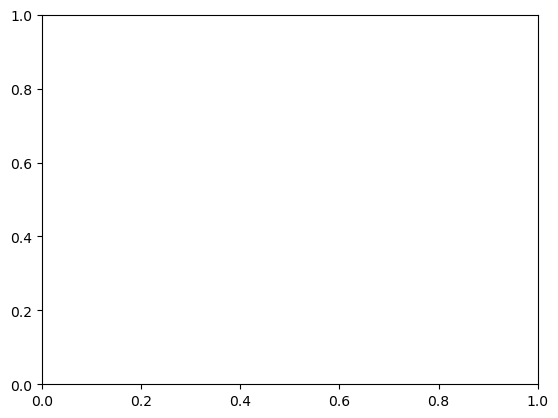

In [17]:
excl = len(df[df.numTrainTrials.lt(71)]['pid'].unique())
print(f'Number of exclusions based on number of practice trials: {excl}')
df_ = df[~df.feedbackOn & df.numTrainTrials.ge(2)].groupby(['condition', 'pid', 'stage'])[['correct', 'confidence']].mean().reset_index()
display(df.head())
fig = plt.figure('Performance')
ax = fig.add_subplot(111)
sns.boxplot(data=df_, y='correct', x='stage', hue='condition', ax=ax, boxprops=dict(alpha=.5))
sns.stripplot(data=df_, y='correct', x='stage', hue='condition', ax=ax, dodge=True)
ax.set_ylim(.4, 1.0)
ax.grid()


print('Mean difference between conditions in test 1')
display(sm.ols('correct ~ condition', data=df_[df_.stage.eq('test1')]).fit().summary())
print('Mean difference between conditions in test 2')
display(sm.ols('correct ~ condition', data=df_[df_.stage.eq('test2')]).fit().summary())

### Difference between test scores

Number of exclusions based on number of practice trials: 9
Mean difference in improvement between conditions


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                pc_diff   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.6819
Date:                Wed, 16 Nov 2022   Prob (F-statistic):              0.510
Time:                        13:10:16   Log-Likelihood:                 74.665
No. Observations:                  53   AIC:                            -143.3
Df Residuals:                      50   BIC:                            -137.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0114      0.015      0.769      0.446      -0.018       0.041
condition_[T.free]           -0.0237      0.020     -1.167      0.249      -0.065       0.017
condition_[T.interleaved]    -0.0115      0.021     -0.553      0.583      -0.053       0.030
==============================================================================
Omnibus:                        1.539   Durbin-Watson:                   2.538
Prob(Omnibus):                  0.463   Jarque-Bera (JB):                1.138
Skew:                          -0.077   Prob(JB):                        0.566
Kurtosis:                       2.299   Cond. No.                         3.80
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

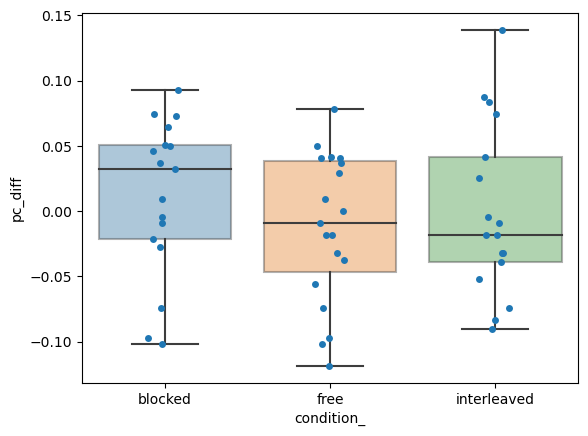

In [42]:
excl = len(df[df.numTrainTrials.lt(200)]['pid'].unique())
print(f'Number of exclusions based on number of practice trials: {excl}')
df_ = df[~df.feedbackOn & df.numTrainTrials.ge(200)].groupby(['condition', 'pid', 'stage'])[['correct', 'confidence']].mean().reset_index()
wide = pd.pivot(df_, index=['pid', 'condition'], columns='stage', values=['correct', 'confidence']).dropna().reset_index()
wide.columns = ['_'.join(col).strip() for col in wide.columns.values]
wide['pc_diff'] = wide.correct_test2 - wide.correct_test1
wide['conf_diff'] = wide.confidence_test2 - wide.confidence_test1
# wide.columns = ['pid', 'pc1, conf1', 'pc2', 'conf2']

fig = plt.figure('Diff')
ax = fig.add_subplot(111)
sns.boxplot(data=wide.sort_values(by='condition_'), y='pc_diff', x='condition_', ax=ax, boxprops=dict(alpha=0.4))
sns.stripplot(data=wide.sort_values(by='condition_'), y='pc_diff', x='condition_', ax=ax)

print('Mean difference in improvement between conditions')
display(sm.ols('pc_diff ~ condition_', data=wide).fit().summary())

# Learning

/home/aten/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/aten/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/aten/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/aten/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<AxesSubplot:xlabel='beta', ylabel='Count'>

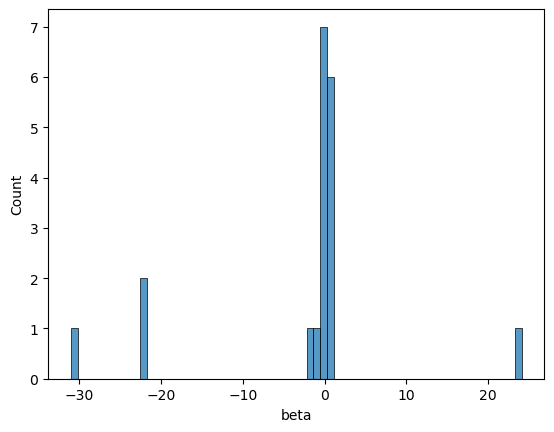

In [35]:
def fit_betas(df):
    y = df.correct.to_numpy().astype(int)
    x = df.confidence.to_numpy().astype(int)
    try:
        logmod = Logit(y, add_constant(x)).fit(disp=0)
        beta = logmod.params[1]
    except:
        beta = np.nan
    return beta

df_ = df[df.stage.str.contains('epochs') & df.numTrainTrials.ge(20)].groupby(['pid'])[['correct', 'confidence']].apply(fit_betas).reset_index()
df_ = df_.rename(columns={0: 'beta'}).fillna(0.0)

# sns.boxplot(data=df_, x='condition', y='beta', hue='famInd', showfliers = False, boxprops=dict(alpha=0.4))
# sns.stripplot(data=df_, x='condition', y='beta', hue='famInd', dodge=True)
# plt.gca().grid()
# plt.gca().set_ylim(-.035, .035)

sns.histplot(x='beta', data=df_)

,trialsComplete,correct,confidence
0,1,0.421053,0.272632
1,2,0.631579,0.677895
2,3,0.315789,0.598421
3,4,0.473684,0.495263
4,5,0.631579,0.557368


<AxesSubplot:xlabel='confidence', ylabel='correct'>

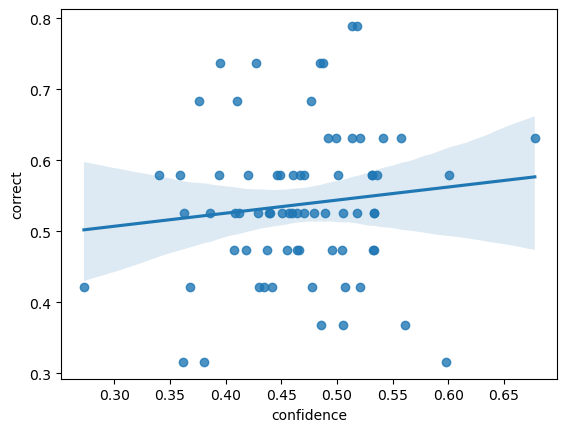

In [36]:
df_ = df.groupby('trialsComplete')[['correct', 'confidence']].mean().reset_index()
display(df_.head())
plt.figure()
sns.regplot(x='confidence', y='correct', data=df_)

<AxesSubplot:xlabel='correct', ylabel='Count'>

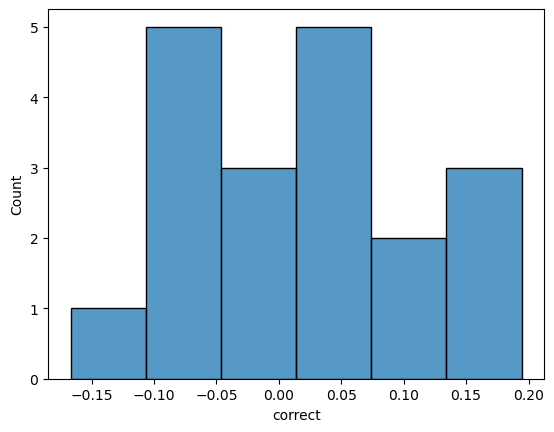

In [34]:
def diff(df):
    l = len(df)
    return -df.iloc[0:l//2].mean() + df.iloc[l//2:].mean()

df_ = df.groupby('pid')[['correct', 'confidence']].apply(diff)
sns.histplot(data=df_, x='correct')
